In [2]:
import numpy as np
import pandas as pd
import os
import random

import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from torch.utils.data.dataloader import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import pickle
import matplotlib.pyplot as plt

from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR


In [3]:
import os, math, time, random, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader



SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config = {'device':device, 'learning_rate': 0.001,'epochs':20}
torch.backends.cudnn.benchmark = True   # speeds up GPU kernels once shapes stabilize

In [4]:
import urllib.request

DATA_DIR = "/content/jena_climate"
os.makedirs(DATA_DIR, exist_ok=True)
zip_local = os.path.join(DATA_DIR, "jena_climate_2009_2016.csv.zip")
csv_local = os.path.join(DATA_DIR, "jena_climate_2009_2016.csv")

if not os.path.exists(csv_local):
    url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
    urllib.request.urlretrieve(url, zip_local)
    with zipfile.ZipFile(zip_local, "r") as zf:
        zf.extractall(DATA_DIR)

df_raw = pd.read_csv(csv_local)
print(df_raw.shape)
df_raw.head()


(420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [5]:
df_raw["Date Time"] = pd.to_datetime(df_raw["Date Time"], format="%d.%m.%Y %H:%M:%S")
df_full = df_raw.set_index("Date Time")


wv = df_full["wv (m/s)"]
df_full.loc[wv < -9000, "wv (m/s)"] = 0.0
maxwv = df_full["max. wv (m/s)"]
df_full.loc[maxwv < -9000, "max. wv (m/s)"] = 0.0

df = df_full.resample("1h").mean() # average downsampling.
df = df.dropna()   # drop any incomplete boundary hours

In [6]:
FEATURE_COLS = list(df.columns)          # all weather variables are used as multivariate input
TARGET_COL = "T (degC)"                    # we forecast temperature only
print(f"{len(FEATURE_COLS)} input features:", FEATURE_COLS)

data = df[FEATURE_COLS].values.astype(np.float32)
target_idx = FEATURE_COLS.index(TARGET_COL)

train_end = int(len(df) * 0.7)
val_end = int(len(df) * 0.85)

train_data = data[:train_end]
val_data = data[train_end:val_end]
test_data = data[val_end:]

# Normalize using train statistics only (avoid leakage)
mean = train_data.mean(axis=0, keepdims=True)
std = train_data.std(axis=0, keepdims=True) + 1e-8

train_norm = (train_data - mean) / std
val_norm = (val_data - mean) / std
test_norm = (test_data - mean) / std

target_mean, target_std = mean[0, target_idx], std[0, target_idx]


14 input features: ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']


window sliding the dataset:

In [7]:
INPUT_HOURS = 720
OUTPUT_HOURS = 24

class WeatherWindowDataset(Dataset):
    """Sliding-window dataset over a (T, F) normalized array."""
    def __init__(self, arr, input_len, output_len, target_idx, stride=1):
        self.arr = arr
        self.input_len = input_len
        self.output_len = output_len
        self.target_idx = target_idx
        self.stride = stride
        self.starts = list(range(0, len(arr) - input_len - output_len + 1, stride))

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, idx):
        s = self.starts[idx]
        x = self.arr[s : s + self.input_len]                                   # (input_len, F)
        y = self.arr[s + self.input_len : s + self.input_len + self.output_len, self.target_idx]  # (output_len,)
        return torch.from_numpy(x), torch.from_numpy(y)

# A stride > 1 skips over most of the overlapping windows so an epoch doesn't take forever.
# stride=24 -> roughly one training window per day instead of one per hour, while still
# covering the full multi-year span. Raise this further (48, 72) if epochs are still too slow
# on your GPU; lower it toward 1 only if you have time/compute to spare.
TRAIN_STRIDE = 6
EVAL_STRIDE = 6

train_ds = WeatherWindowDataset(train_norm, INPUT_HOURS, OUTPUT_HOURS, target_idx, stride=TRAIN_STRIDE)
val_ds   = WeatherWindowDataset(val_norm,   INPUT_HOURS, OUTPUT_HOURS, target_idx, stride=EVAL_STRIDE)
test_ds  = WeatherWindowDataset(test_norm,  INPUT_HOURS, OUTPUT_HOURS, target_idx, stride=EVAL_STRIDE)

BATCH_SIZE = 64
loader_kwargs = dict(num_workers=2, pin_memory=True, persistent_workers=True)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True,  **loader_kwargs)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False, **loader_kwargs)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False, **loader_kwargs)

print(f"train windows: {len(train_ds)} | val windows: {len(val_ds)} | test windows: {len(test_ds)}")
xb, yb = next(iter(train_loader))
print("batch x:", xb.shape, "batch y:", yb.shape)


train windows: 8048 | val windows: 1628 | test windows: 1628
batch x: torch.Size([64, 720, 14]) batch y: torch.Size([64, 24])


In [8]:
class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_len = 2000 ):
    super().__init__()
    pe= torch.zeros(max_len, d_model)
    positions = torch.arange(0,max_len,dtype=torch.float32).unsqueeze(1)
    division_factor = torch.exp(torch.arange(0,d_model,2).float()*1/d_model* -1 *(math.log(10000.0)))
    pe[:,0::2] =torch.sin(positions * division_factor)
    pe[:,1::2] =torch.cos(positions * division_factor)
    self.register_buffer('pe',pe.unsqueeze(0))

  def forward(self, x):
    return x+ self.pe[:,:x.size(1)]

In [9]:
class Transformer(nn.Module):
  def __init__(self, n_features, out_horizon = 24,
               num_heads= 2, num_layers=2, max_len = 2000, dropout = 0.1):
    super().__init__()
    d_model = n_features
    feed_forward_dimension = 2 * d_model

    self.input_proj = nn.Linear(n_features, d_model) # Added input projection
    self.positional_encoding = PositionalEncoding(d_model, max_len)
    encoder_layer = nn.TransformerEncoderLayer(
        d_model=d_model,
        nhead=num_heads,
        dim_feedforward=feed_forward_dimension,
        dropout= dropout,
        batch_first = True,
        norm_first = True
    )
    self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    self.final_ln = nn.LayerNorm(d_model)
    self.head = nn.Sequential(
        nn.Linear(d_model, d_model), nn.GELU(), nn.Linear(d_model, out_horizon)
    )
  def forward(self, x):
      # x: (B, T, n_features)
      x = self.input_proj(x)
      x = self.positional_encoding(x) # Corrected attribute name
      x = self.encoder(x)
      x = self.final_ln(x)
      last_step = x[:, -1, :]         # sequence-to-one: use representation at the final time step
      return self.head(last_step)


In [10]:
model = Transformer(n_features = 14 ). to(config["device"])


/tmp/ipykernel_1730/1868294780.py:18: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


In [11]:
import torch


def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """returns the metrics coming from this epoch. returns train_metrics(dict):

    {train_loss:, train_accuracy:}
    """
    model.train()
    # sets the evaluation parameters to zero first
    total_epoch_loss = 0
    training_correct = 0
    training_total = 0
    for batch_features, batch_labels in train_loader:
        # Move batch_features and batch_labels to the correct device
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        total_epoch_loss += loss.item()
        loss.backward()
        optimizer.step()

        # --- FIX: Shifted from discrete classification to continuous regression ---
        # Instead of classification accuracy, we compute Mean Absolute Error (MAE)
        # as the secondary physical performance metric.
        training_correct += torch.abs(outputs - batch_labels).sum().item()
        training_total += (
            batch_labels.numel()
        )  # Total number of continuous target values predicted

    average_loss = total_epoch_loss / len(train_loader)

    # We keep your exact dictionary keys intact, but map the regression metric to 'train_accuracy'
    training_metrics = {
        "train_loss": average_loss,
        "train_accuracy": training_correct / training_total,
    }
    return training_metrics

In [12]:
import torch
import torch.nn as nn


def test_one_epoch(model, test_loader, device, lossfn=nn.MSELoss()):
    """Runs an evaluation pass over the test loader and computes the average loss

    and overall metric performance.
    """
    model.eval()
    total_loss = 0.0
    total_samples = 0
    running_metric_error = 0.0  # Tracks absolute deviations for evaluation

    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            # Forward pass
            output = model(batch_features)  # Shape: (Batch, output_len)
            loss = lossfn(output, batch_labels)

            # Accumulate loss metrics
            total_loss += loss.item() * batch_features.size(0)
            total_samples += batch_features.size(0)

            # Track mean absolute error as a proxy for physical performance
            running_metric_error += (
                torch.abs(output - batch_labels).sum().item()
            )

    # Compute final averages across the full dataset
    loss_avg = total_loss / total_samples
    mae_accuracy = running_metric_error / (
        total_samples * test_loader.dataset.output_len
    )

    return loss_avg, mae_accuracy

In [13]:
def run_model(model, config, train_loader, test_loader, schedule= False):
  """
  complete main loop
  """
  lossfn = nn.MSELoss()
  optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])
  if schedule:
    warmup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)
    cosine = CosineAnnealingLR(optimizer, T_max=45, eta_min=1e-5)
    scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])
  history = {"training_loss": [], "validation_accuracy" : [], "training_accuracy":[], "ece":[], "validation_loss":[]}
  training_epoch_losses = []
  validation_accuracy =[]
  training_accuracy = []

  for epoch in range(config["epochs"]):
    print(epoch, "out of ", config["epochs"])
    epoch_metrics = train_one_epoch(model, train_loader, lossfn, optimizer, device)
    history["training_loss"].append(epoch_metrics['train_loss'])
    history["training_accuracy"].append(epoch_metrics['train_accuracy'])
    print("testing phase going to begin")
    accuracy, validation_loss= test_one_epoch(model, test_loader, device)
    print("training phase going to begin")
    history["validation_loss"].append(validation_loss)
    history["validation_accuracy"].append(accuracy)
    print(history["validation_accuracy"][-1])

  return history, model

In [16]:
model = Transformer(n_features = 14 ). to(config["device"])
history, model = run_model(model, config, train_loader, val_loader)

/tmp/ipykernel_1730/1868294780.py:18: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


0 out of  20
testing phase going to begin
training phase going to begin
0.244994975498326
1 out of  20
testing phase going to begin
training phase going to begin
0.18470180691826255
2 out of  20
testing phase going to begin
training phase going to begin
0.16619400793562944
3 out of  20
testing phase going to begin
training phase going to begin
0.14898604099668508
4 out of  20
testing phase going to begin
training phase going to begin
0.1445489174867145
5 out of  20
testing phase going to begin
training phase going to begin
0.1379471779492036
6 out of  20
testing phase going to begin
training phase going to begin
0.12526789243522968
7 out of  20
testing phase going to begin
training phase going to begin
0.10949557025617113
8 out of  20
testing phase going to begin
training phase going to begin
0.1064196253694246
9 out of  20
testing phase going to begin
training phase going to begin
0.10316717368378979
10 out of  20
testing phase going to begin
training phase going to begin
0.1042043144

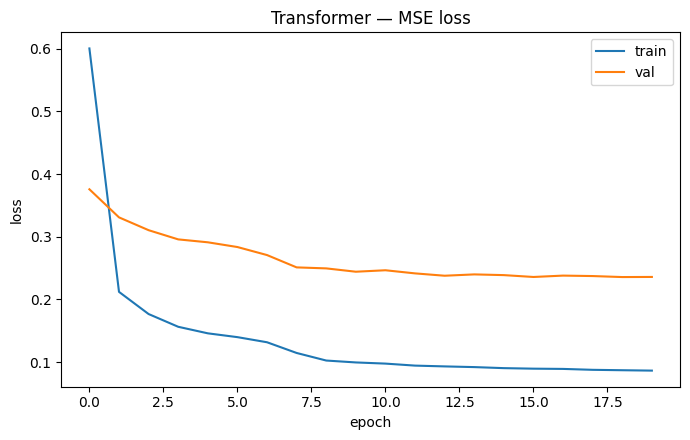

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4.5))
plt.plot(history["training_loss"], label="train")
plt.plot(history["validation_loss"], label="val")
plt.title("Transformer — MSE loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
plt.tight_layout()
plt.show()


In [18]:
def evaluate(model, loader):
    model.eval()
    preds_all, targets_all = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            preds = model(xb).cpu().numpy()
            preds_all.append(preds)
            targets_all.append(yb.numpy())
    preds_all = np.concatenate(preds_all, axis=0)
    targets_all = np.concatenate(targets_all, axis=0)

    # de-normalize back to degrees C
    preds_c = preds_all * target_std + target_mean
    targets_c = targets_all * target_std + target_mean

    mae = np.mean(np.abs(preds_c - targets_c))
    rmse = np.sqrt(np.mean((preds_c - targets_c) ** 2))

    # error as a function of how far into the 24h horizon we are (long-range dependency proxy)
    per_step_mae = np.mean(np.abs(preds_c - targets_c), axis=0)  # (24,)

    return {"mae": mae, "rmse": rmse, "per_step_mae": per_step_mae,
            "preds_c": preds_c, "targets_c": targets_c}

test_eval = evaluate(model, test_loader)
print(f"Transformer -> MAE: {test_eval['mae']:.3f} degC | RMSE: {test_eval['rmse']:.3f} degC")


Transformer -> MAE: 1.873 degC | RMSE: 2.442 degC


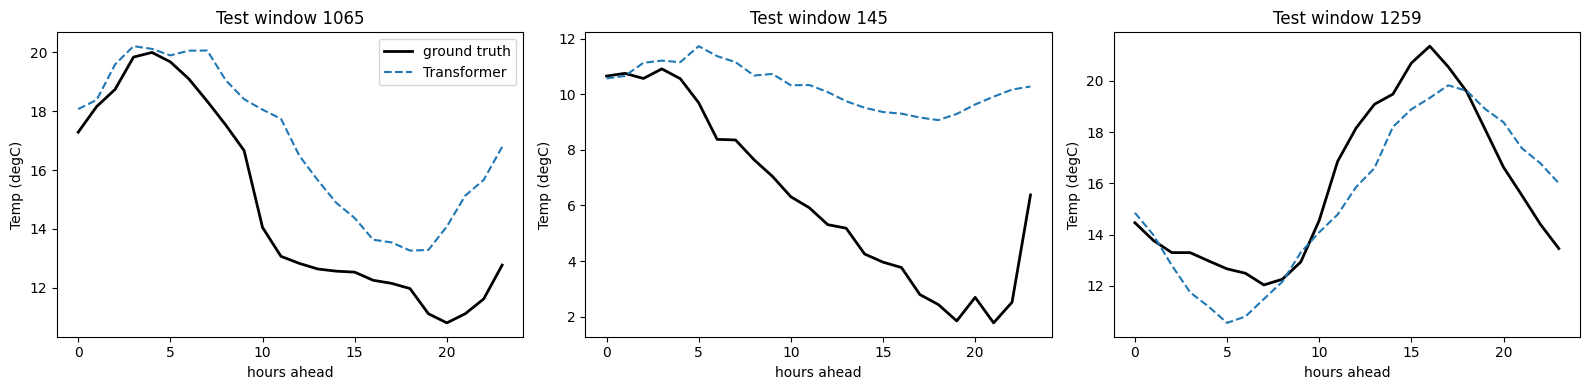

In [19]:
rng = np.random.default_rng(SEED)
sample_idxs = rng.choice(len(test_eval["targets_c"]), size=3, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, idx in zip(axes, sample_idxs):
    ax.plot(test_eval["targets_c"][idx], label="ground truth", color="black", linewidth=2)
    ax.plot(test_eval["preds_c"][idx], label="Transformer", linestyle="--")
    ax.set_title(f"Test window {idx}")
    ax.set_xlabel("hours ahead"); ax.set_ylabel("Temp (degC)")
axes[0].legend()
plt.tight_layout()
plt.show()


1. why attention helps sequence modelling:

attention is a mechanism that helps embeddings carry context given by ** all** embeddings around it within 1 layer itself. This is especially useful in sequence modelling, where the sequence length can be very long and thus reccurence causes loss of info of very old words.

2. difference between reccurence and attention

recurrence means that a static hidden state or states(static as in non dependent on the next word) is carried forward for the next word.
 in attention, each new successive word depends on every previous word and updates its own interpretation. thus we obtain a dynamic representation of words so far.

 3. Where LSTMs are better than transformeers:

 in order to understand positional encoding to a certain extent(ie learn relative positions between words), the transformer architecutre requires a lot of data. Thus, LSTMs can be used in cases where SEQUENTIAL nature of the task is highly apparent and the dataset is small.

 4. when Transformers are prefered:

 when the data is large/ when the input sequence is complex and large.